# 2. Threshold values

In this chapter a threshold discharge will be determined by connecting historical droughts in the Okavango Delta with the discharge data at Mohembo (DEAfrica Team, 2021). Figure 2.1 below shows the location of Mohembo with respect to the Okavango Delta (Alamy, n.d.). First, the discharge data will be analyzed, and threshold values will be determined for years that clearly show lower values. The data used in this study comes from Digital Earth Africa (DEAfrica Team, 2021). After the analysis, the years that fall below the threshold values will be connected with the historic dry years mentioned in the introduction. Lastly, the droughts will be categorized based on quantile values. 

<div align="center">
<figure>
  <img src="Figures/LocationMohembo.png" width="400">
  <figcaption><i>Figure 2.1: location of Mohembo (Alamy, n.d.)</i></figcaption>
</figure>
</div>

## 2.1 Discharge data analysis
The biggest problems occur when the Okavango Delta experiences droughts in the flood season, as the wildlife moves towards the delta in this period for the floodplains. In figure 2.2 with the data from DEAfrica Team (2021), the discharge variability during the year that is causing the flood season can be clearly seen. The peak flood season occurs between May and September (Gaudaré, et al., 2025). The Okavango River discharge peaks at Mohembo between February and July causing the flooding between May and September, as displayed in figure 2.3.

In [1]:
#Loading packages
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

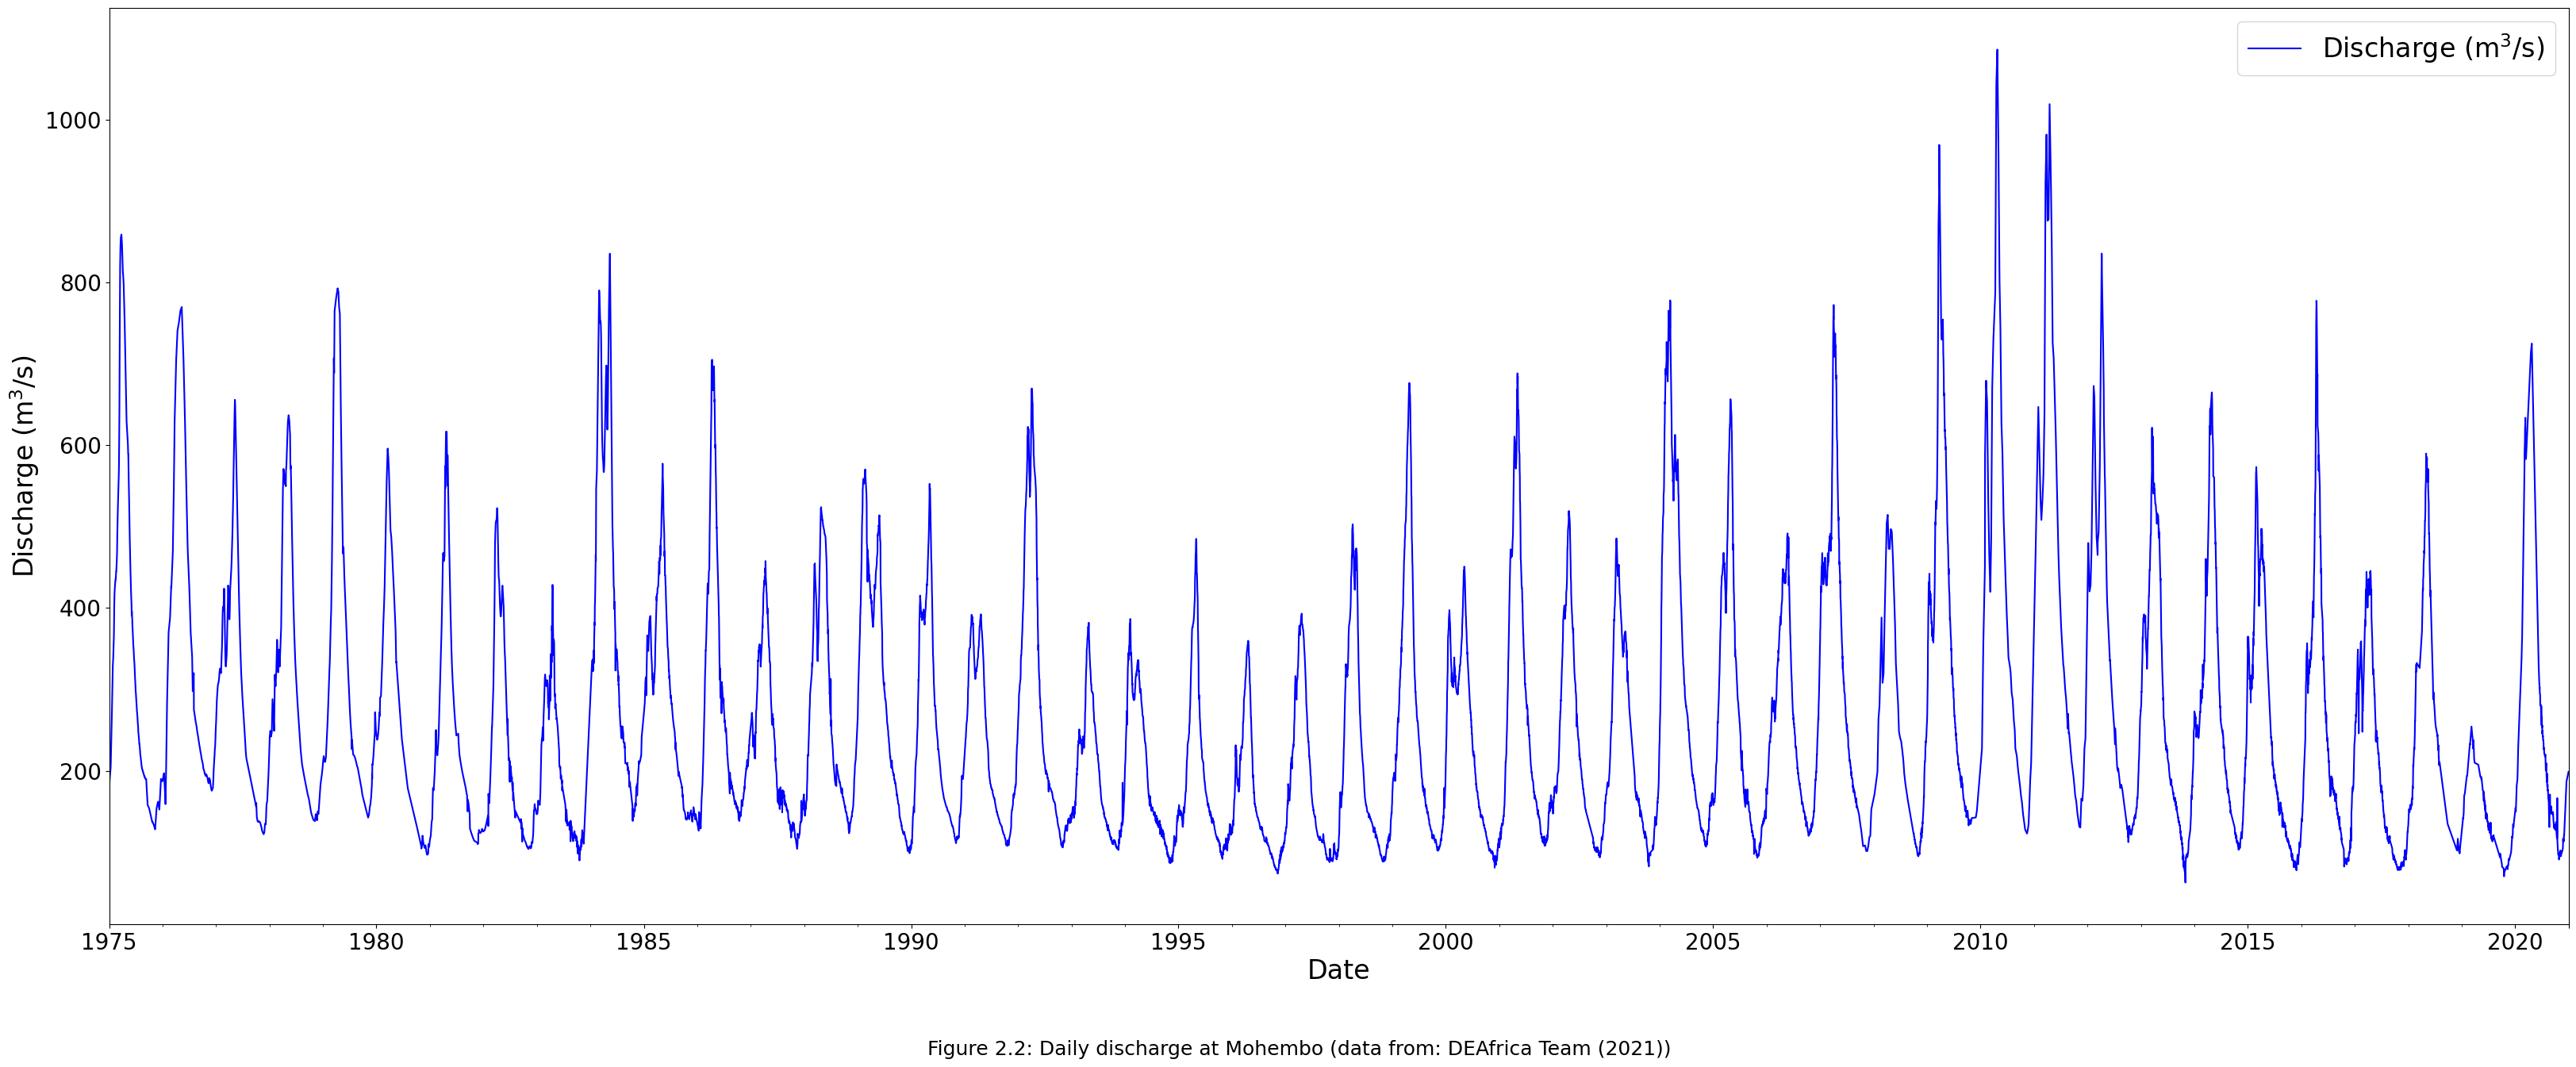

In [27]:
#Loading discharge data
data = pd.read_csv(Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/mohembo_daily_water_discharge_data.csv", 
                   index_col='date', parse_dates=True, dayfirst=True)

#Years with missing data will not lower yearly volume because of the missing data
data_daily = data.resample('D').interpolate() 
data_daily.columns = ['Discharge (m$^3$/s)']

#Excluding years without measurements troughout the whole year
data_daily = data_daily[~data_daily.index.year.isin([1974, 2021])] 

#Plotting daily discharge data
fig, ax = plt.subplots(figsize=(40, 15))
data_daily.plot(ax=ax, color='blue')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m$^3$/s)", fontsize=24)
plt.legend(fontsize=24)
fig.text(0.5, 0,"Figure 2.2: Daily discharge at Mohembo (data from: DEAfrica Team (2021))", ha="center", fontsize=18);

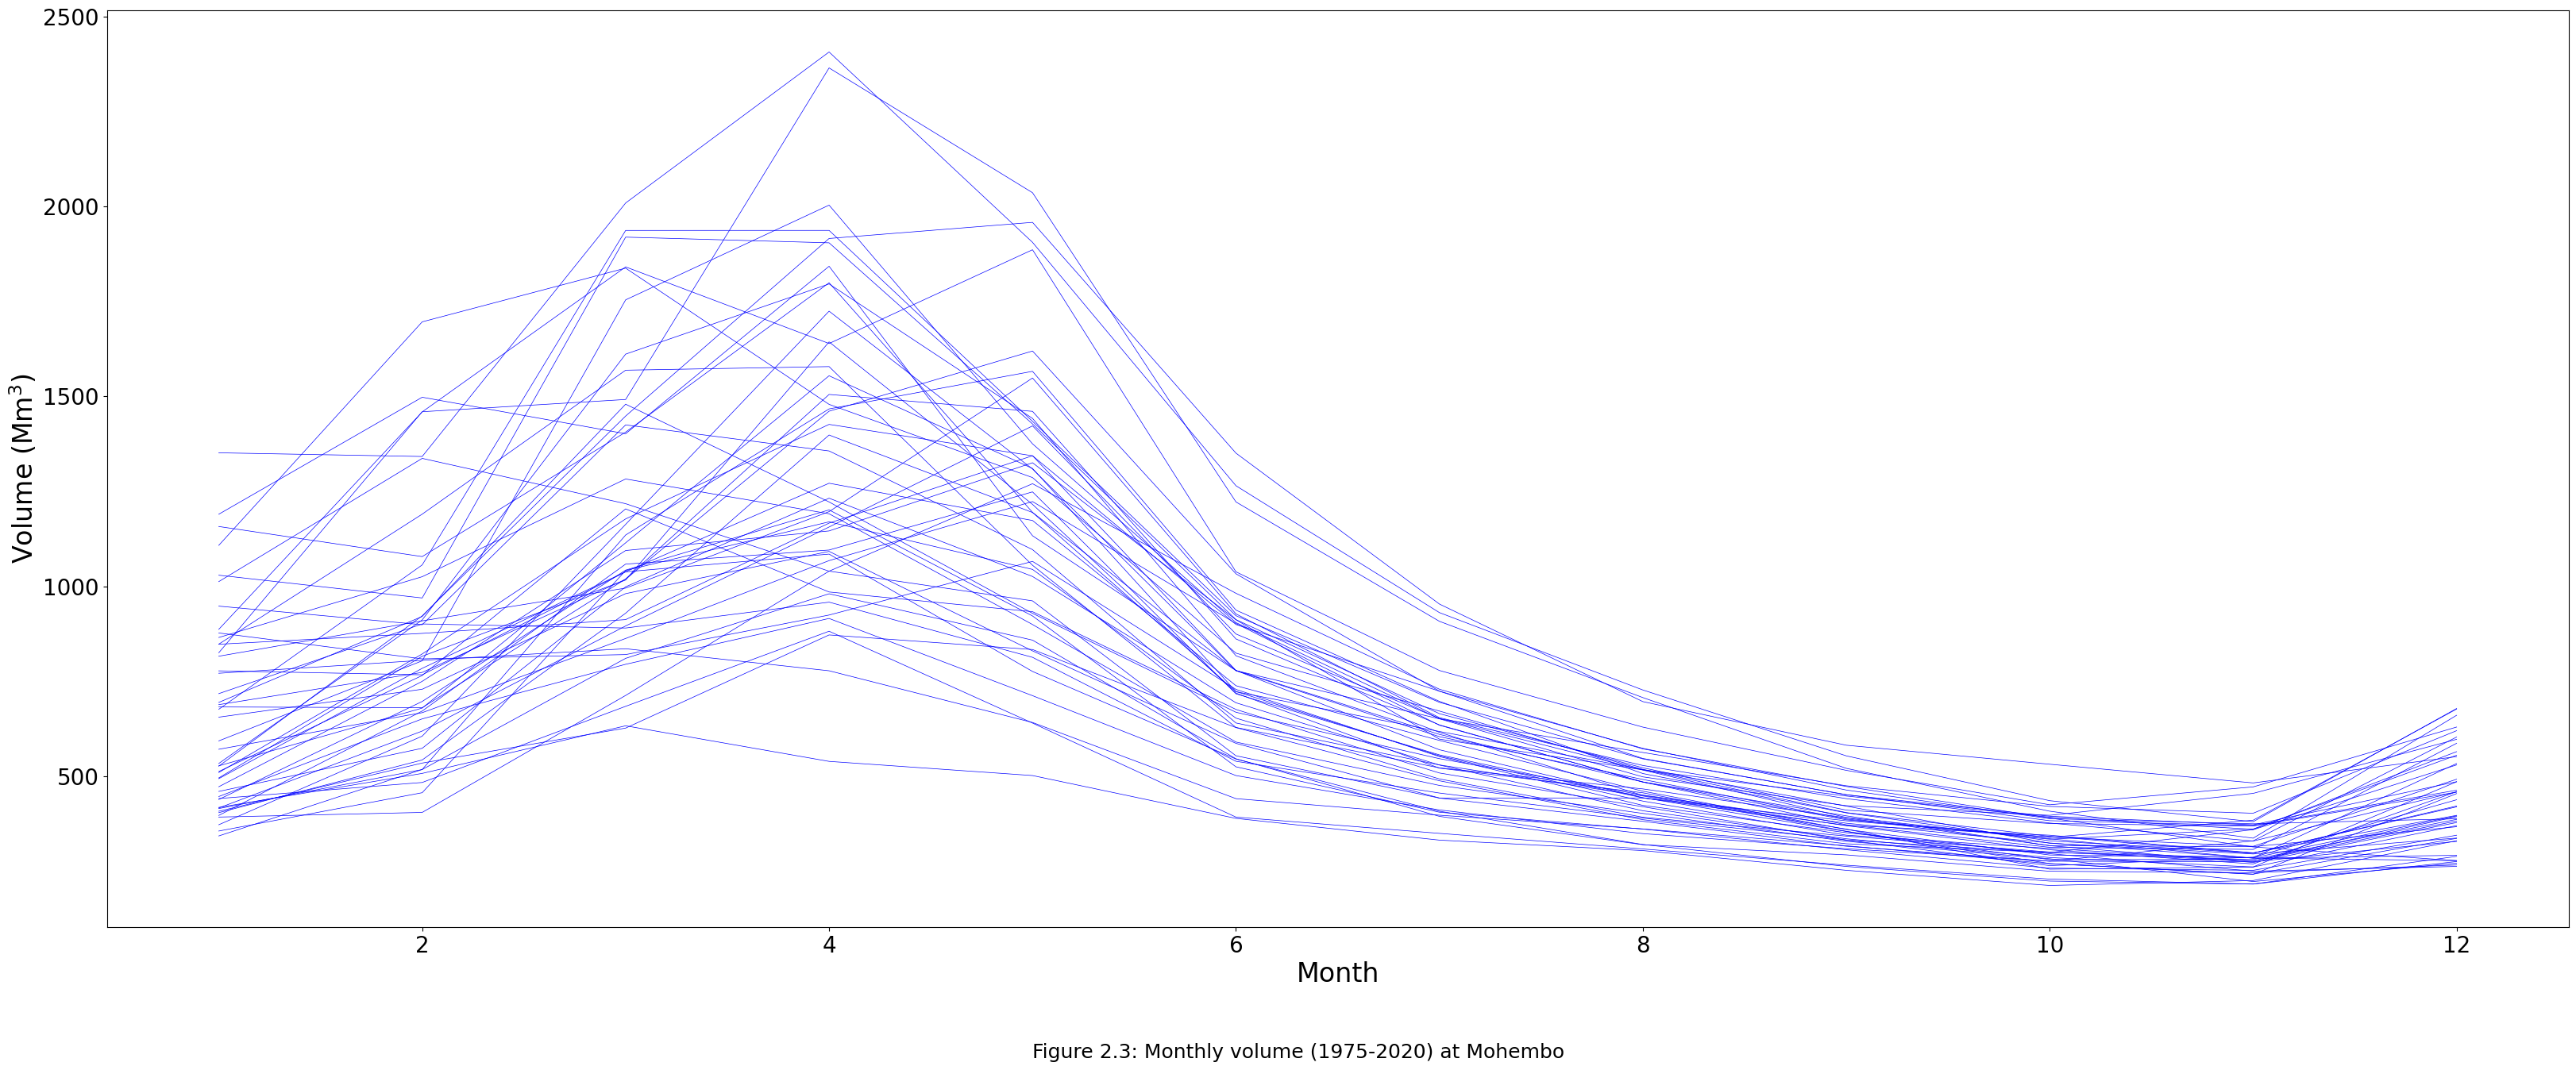

In [3]:
#Convert daily discharge in m^3/s to monthly volume in Mm^3
data_monthly = (data_daily * 3600 * 24).resample('ME').sum() / 1e6 
data_monthly.index = data_monthly.index.month
data_monthly.columns = ['Monthly volume (Mm$^3$)']

#Plotting monthly volume data
fig, ax = plt.subplots(figsize=(40, 15))

#To get rid of the lines connecting December to January
for i in range(len(data_monthly) // 12):
    data_plotted = data_monthly[i * 12 : 12 + i * 12]
    data_plotted.plot(ax=ax, linewidth=0.5, color='blue', legend=False)
    
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Month", fontsize=24)
ax.set_ylabel("Volume (Mm$^3$)", fontsize=24)
fig.text(0.5, 0,"Figure 2.3: Monthly volume (1975-2020) at Mohembo", ha="center", fontsize=18);

Figure 2.4 shows the total yearly volume and the volume between February and July – that causes the flood plains – that the delta receives each year. This study will look at the total yearly volume that the Okavango Delta receives from the river, as it is closely related to the total volume during the flooding period.

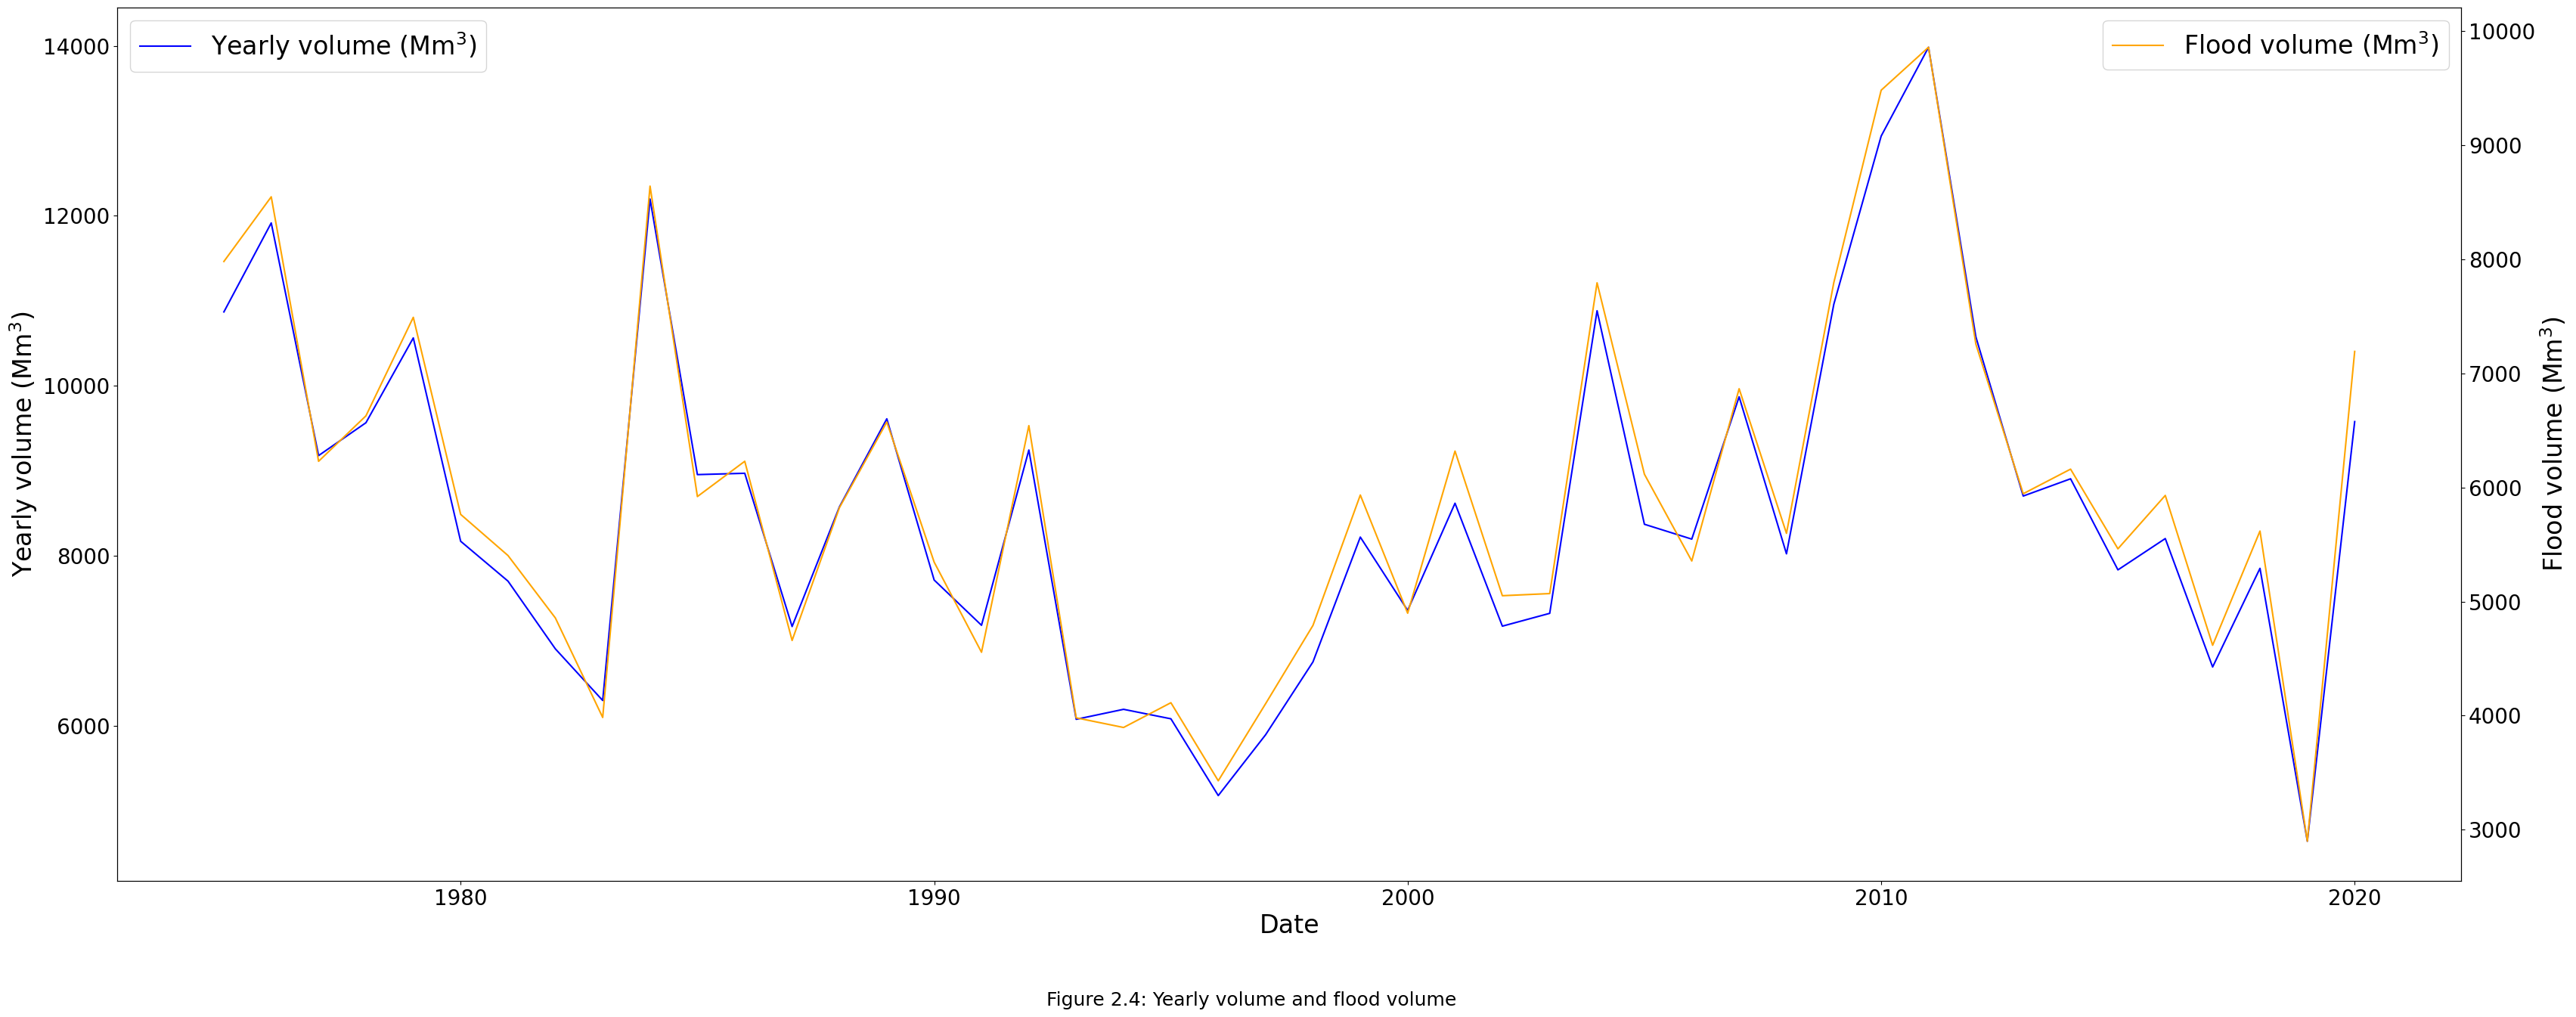

In [4]:
#Convert daily discharge in m^3/s to yearly volume in Mm^3 
yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.index = yearly_volume.index.year
yearly_volume.columns = ['Yearly volume (Mm$^3$)']

#Convert daily discharge in m^3/s to monthly volume in Mm^3 in the months February to July
flood_volume = (data_daily * 3600 * 24)[data_daily.index.month.isin([2,3,4,5,6,7])].resample("YE").sum() / 1e6
flood_volume.index = flood_volume.index.year
flood_volume.columns = ['Flood volume (Mm$^3$)']

#Plotting yearly volume and flood volume
fig, ax = plt.subplots(figsize=(40, 15))
yearly_volume.plot(ax=ax, color='blue')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=24, loc='upper left')

#Seperate y-axis for flood volume on the right side
ax1 = ax.twinx()
flood_volume.plot(ax=ax1, color='orange')
plt.yticks(fontsize=20)
plt.legend(fontsize=24, loc='upper right')

ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm$^3$)", fontsize=24)
ax1.set_ylabel("Flood volume (Mm$^3$)", fontsize=24)
fig.text(0.5, 0,"Figure 2.4: Yearly volume and flood volume", ha="center", fontsize=18);

In this study, years are considered dry if the total yearly volume of the Okavango River at Mohembo falls below the historical 15th percentile threshold. This corresponds to an annual volume of 6591 Mm3. For reverence, the Okavango River supplies the delta with approximately 10,000 Mm3 of water on an annual basis (Andersson, et al., 2003). In figure 2.5, the total yearly volume is shown with the 15th percentile threshold value and the years that do not meet this threshold are shown in table 2.1. The 15th percentile is selected because it captures the lowest yearly incoming volumes visible in figure 2.5. Higher percentile also capture years that not experienced major drought, while lower percentiles only captures the most extreme dry years.

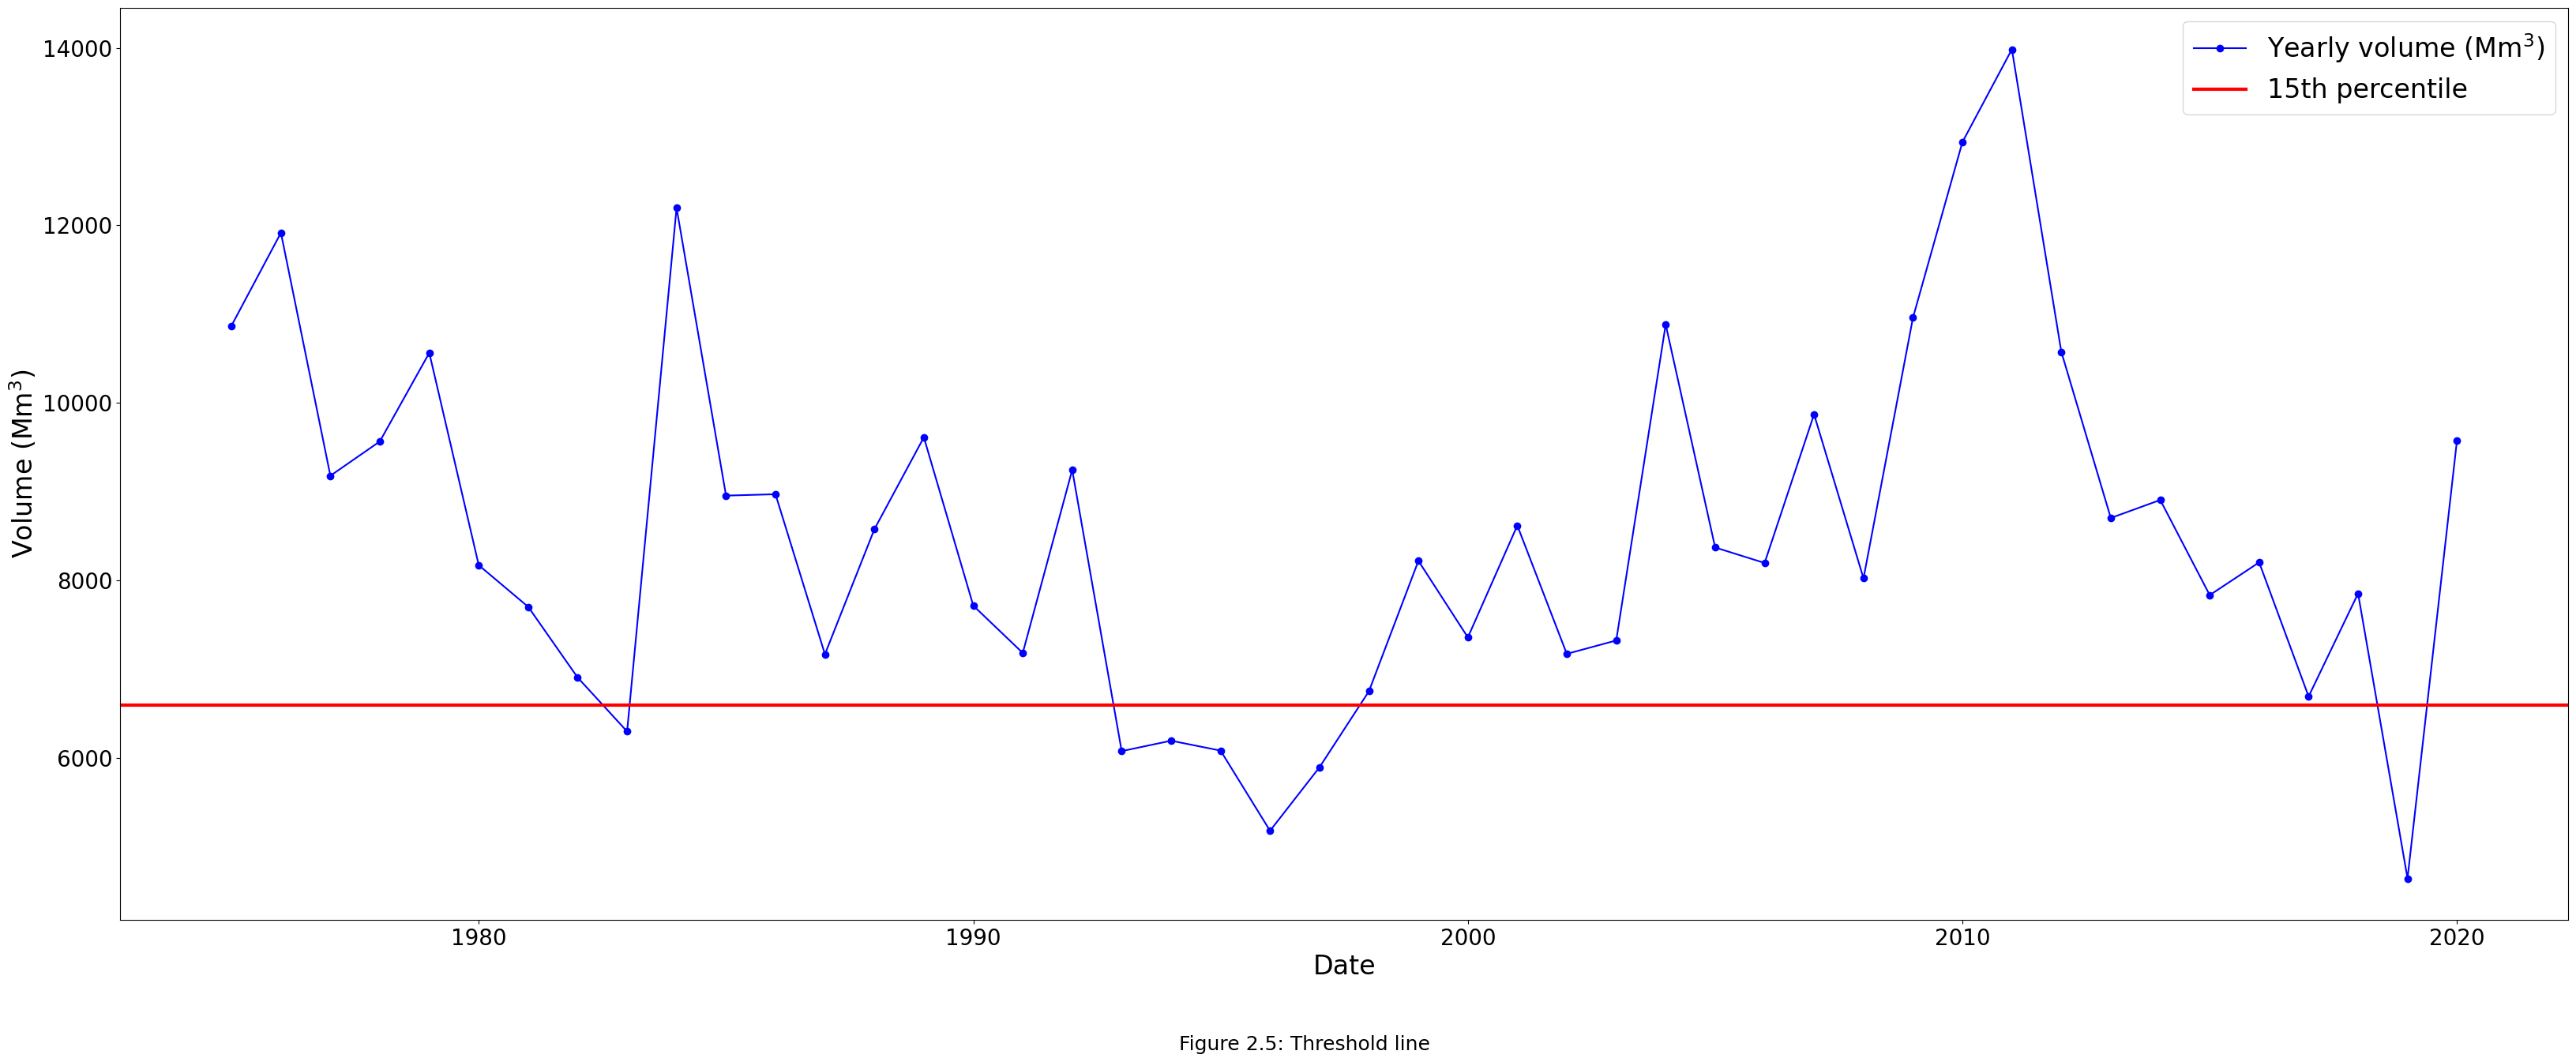

In [5]:
#Plotting yearly volume with 15th percentile line
fig, ax = plt.subplots(figsize=(40, 15))
yearly_volume.plot(ax=ax, marker='o', color='blue')
plt.axhline(y=np.percentile(yearly_volume['Yearly volume (Mm$^3$)'], 15), color='red', linewidth=3, label='15th percentile')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm$^3$)", fontsize=24)
plt.legend(fontsize=24)
fig.text(0.5, 0,"Figure 2.5: Threshold line", ha="center", fontsize=18);

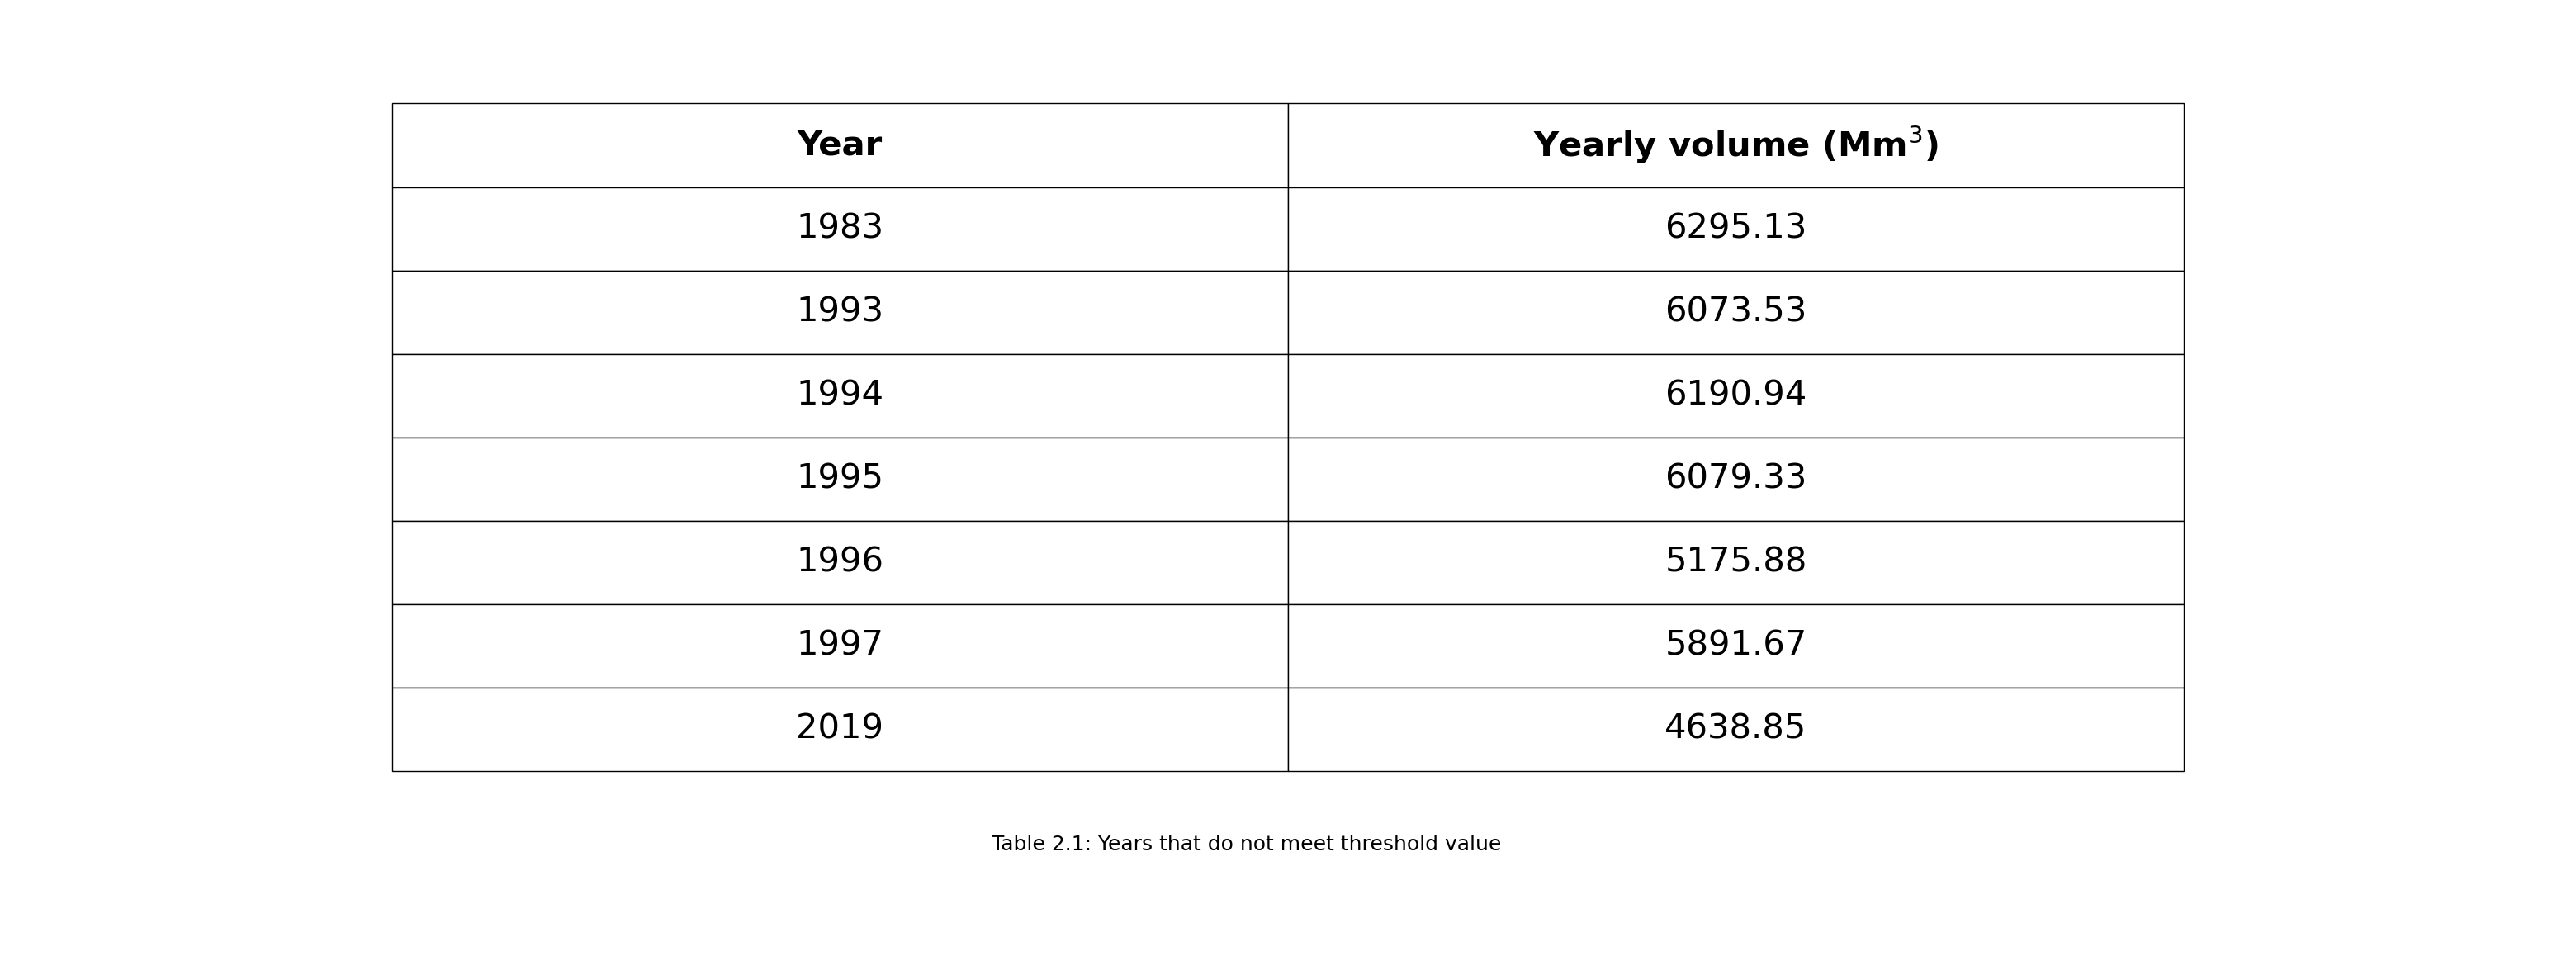

In [6]:
#Computing years that fall below the 15th percentile threshold
percentile15 = np.percentile(yearly_volume, 15)
drought_years = yearly_volume[yearly_volume['Yearly volume (Mm$^3$)'] < percentile15]

#Changing dataframe to put it in a table
drought_years = drought_years.round(2)
drought_years = drought_years.reset_index()
drought_years.columns = ['Year', 'Yearly volume (Mm$^3$)']

#Plotting table
fig, ax = plt.subplots(figsize=(40, 15))
ax.axis('off')

table = ax.table(
    cellText=drought_years.astype(str).values,
    colLabels=drought_years.columns,
    cellLoc='center',
    bbox=[0.15, 0.2, 0.7, 0.7],
)

#Making labels bold
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

table.set_fontsize(30)
fig.text(0.5, 0.2,"Table 2.1: Years that do not meet threshold value", ha="center", fontsize=18);

## 2.2 Connecting result to historical events
As mentioned in the introduction, the Okavango River supplies about 75% of the Okavango Delta’s water supply (Hamandawana, et al., 2007). Due to the majority of the water supply of the delta coming from the river, the discharge data of the river can be connected to the dry years in the Okavango Delta. 

The Okavango Delta experienced one of its worst droughts in 2019 (Bhuiyan, 2019). In table 2.1 and the graphs in chapter 2.1, it can be seen that 2019 has the lowest yearly volume of all the recorded years. As mentioned in the introduction, there was a significant decrease in wildlife populations because of the droughts in the 1990s (Mail & Guardian, 2011). Again, this is also reflected in table 2.1 and in figure 2.4 in chapter 2.1. The area Letsholathebe, at the end of the Okavango Delta, was very bare in 1983 because of drought (Hamandawana, et al., 2007). This resulted that the wildlife could not graze in this area. One of the reasons for the bare ground is probably the fact that the water supply was too low for the growth of vegetation. 

To use the discharge data at Mohembo to determine dry periods in the Okavango Delta, also years with big floodings should be reflected in the graph in figure 2.4. In 1984, the Okavango delta experienced a massive flood (Expert Africa, n.d.). In figure 5, there is a clear peak of the yearly volume. Between 2010 and 2012, the Okavango Delta ‘saw some of the largest floods in recent memory’ (Okavango Delta, n.d.). Again, this can be seen in figure 2.4, with the biggest peak occurring in 2010 and the yearly volumes of 2011 and 2012 staying well above the determined threshold values.

To conclude, the discharge data at Mohembo can be used as an indicator for dry periods in the Okavango Delta because the lows and highs in the yearly volumes can be connected with historical events.


## 2.3 Drought categories
Based on different percentiles, the droughts will be categorized into three levels: moderate, severe, and extreme. In table 2.2, the ranges for the different categories are given and the historical dry years have been given a drought level.

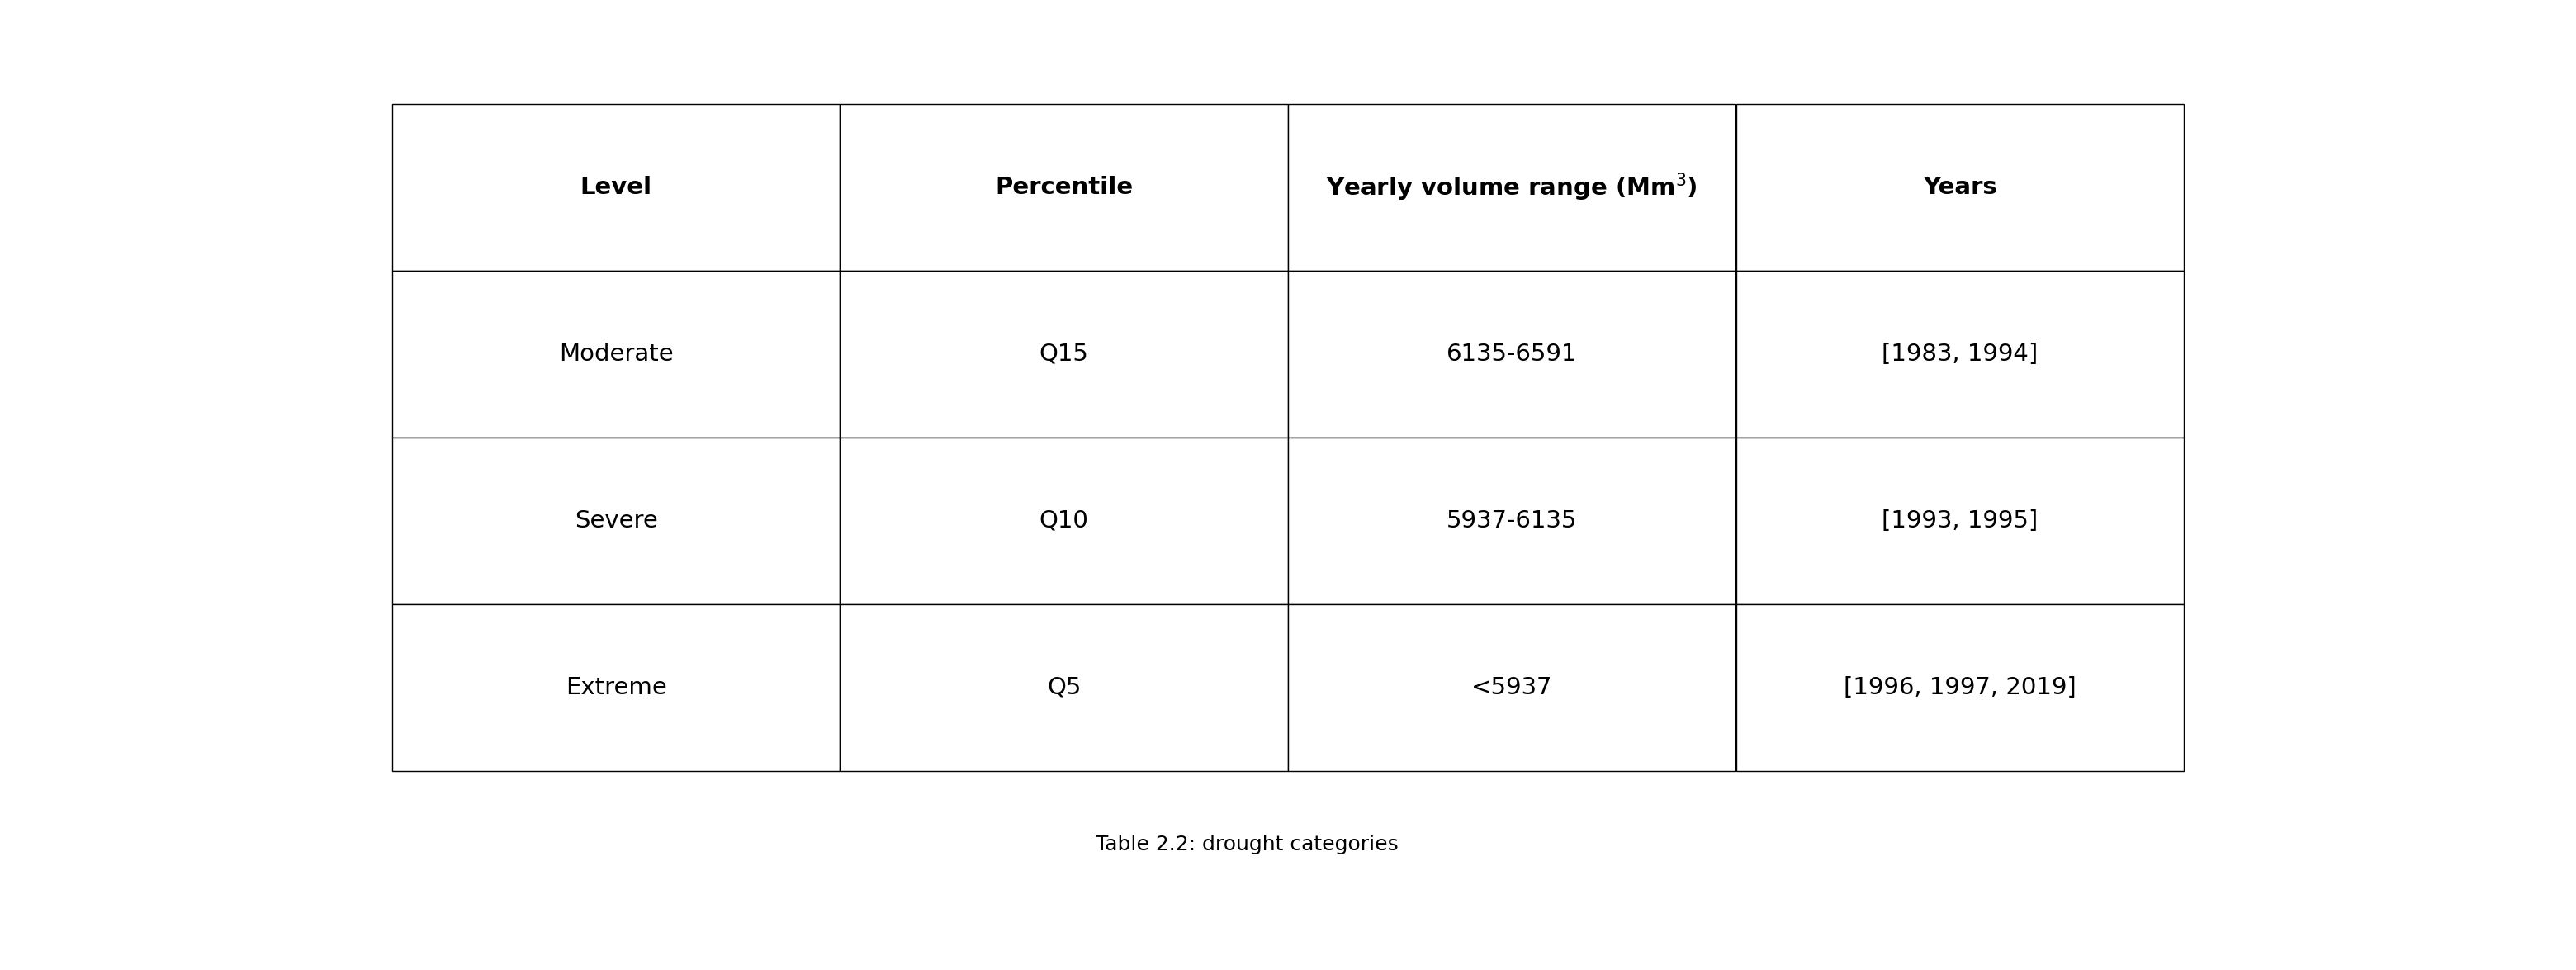

In [26]:
#Calculating different percentiles
percentile15 = np.percentile(yearly_volume, 15)
percentile10 = np.percentile(yearly_volume, 10)
percentile5 = np.percentile(yearly_volume, 5)

#Catogorize dry years according to the percentiles
moderate_years = yearly_volume[(yearly_volume['Yearly volume (Mm$^3$)'] < percentile15) 
                    & (yearly_volume['Yearly volume (Mm$^3$)'] > percentile10)]
severe_years = yearly_volume[(yearly_volume['Yearly volume (Mm$^3$)'] < percentile10) 
                    & (yearly_volume['Yearly volume (Mm$^3$)'] > percentile5)]
extreme_years = yearly_volume[yearly_volume['Yearly volume (Mm$^3$)'] < percentile5]

#Making dataframe 
level = ['Moderate', 'Severe', 'Extreme']
percentile = ['Q15', 'Q10', 'Q5']
volume_range = [f'{percentile10:.0f}-{percentile15:.0f}', f'{percentile5:.0f}-{percentile10:.0f}', f'<{percentile5:.0f}']
catogorized_years = [f'{moderate_years.index.tolist()}', f'{severe_years.index.tolist()}', f'{extreme_years.index.tolist()}']
df = pd.DataFrame({
    'Level': level,
    'Percentile': percentile,
    'Yearly volume range (Mm$^3$)': volume_range,
    'Years': catogorized_years
})

#Plotting table
fig, ax = plt.subplots(figsize=(40, 15))
ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    bbox=[0.15, 0.2, 0.7, 0.7]
)

#Making labels bold
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

table.set_fontsize(30)
fig.text(0.5, 0.2,"Table 2.2: drought categories", ha="center", fontsize=18);